In [20]:
##############################################################################
# 1) IMPORTS AND INITIAL SETUP

import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable
import seaborn as sns
import pandas as pd

# For splitting dataset and model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.decomposition import PCA

# For evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Deep learning
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout,
    Bidirectional, Attention, Input, LayerNormalization
)

In [21]:
!pip install shap

In [22]:
##############################################################################
# NEW: IMPORTS FOR DATA AUGMENTATION AND EXPLAINABILITY (SHAP)
##############################################################################
import random
# If running locally or on some platforms, uncomment to install shap:

import shap

In [23]:
##############################################################################
# 2) DATASET PATH
##############################################################################
# NOTE: This path should point to your Asthma Detection Dataset Version 2
dataset_path = r'C:\Users\omarz\OneDrive\Desktop\p2m\respiratory_diseases\Asthma Detection Dataset Version 2\Asthma Detection Dataset Version 2'

# The five categories/folders we have in the dataset
categories = ['Bronchial', 'pneumonia', 'asthma', 'healthy', 'copd']

# Print out the list of categories
print("Categories:", categories)


Categories: ['Bronchial', 'pneumonia', 'asthma', 'healthy', 'copd']


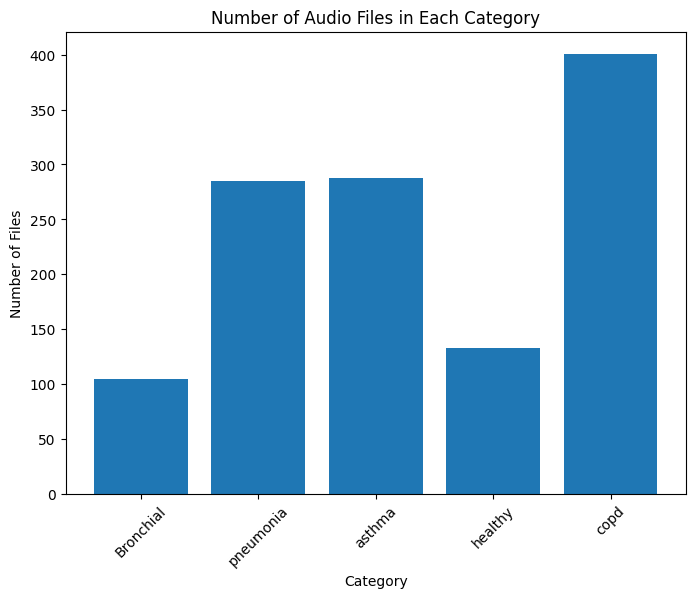

In [24]:
##############################################################################
# 3) BAR CHART: NUMBER OF AUDIO FILES IN EACH CATEGORY
##############################################################################
# Count how many .wav files exist in each category folder
category_counts = {
    category: len([
        f for f in os.listdir(os.path.join(dataset_path, category)) 
        if f.endswith('.wav')
    ])
    for category in categories
}

# Plot a bar chart of category counts
plt.figure(figsize=(8, 6))
plt.bar(category_counts.keys(), category_counts.values())
plt.xlabel('Category')
plt.ylabel('Number of Files')
plt.title('Number of Audio Files in Each Category')
plt.xticks(rotation=45)
plt.show()

In [25]:
##############################################################################
# 4) TABLE: NUMBER OF AUDIO FILES IN EACH CATEGORY
##############################################################################
# Create a PrettyTable to show the category counts
table = PrettyTable()
table.field_names = ["Category", "Number of Audio Files"]
for category, count in category_counts.items():
    table.add_row([category, count])

print("Number of Audio Files in Each Category:")
print(table)


Number of Audio Files in Each Category:
+-----------+-----------------------+
|  Category | Number of Audio Files |
+-----------+-----------------------+
| Bronchial |          104          |
| pneumonia |          285          |
|   asthma  |          288          |
|  healthy  |          133          |
|    copd   |          401          |
+-----------+-----------------------+



=== Waveform Examples for Each Category ===


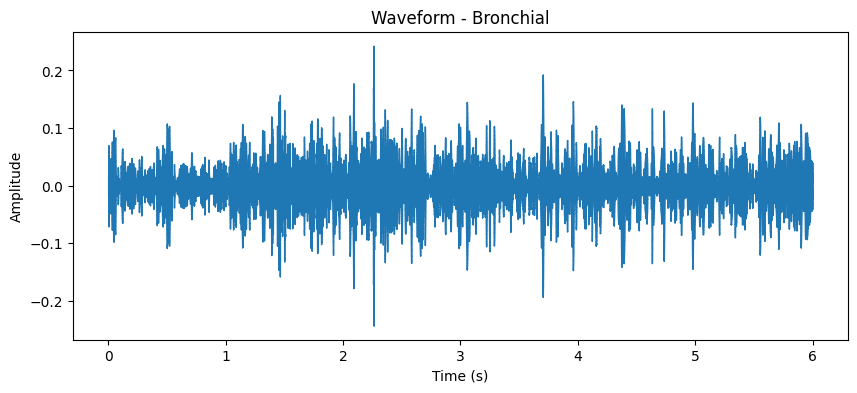

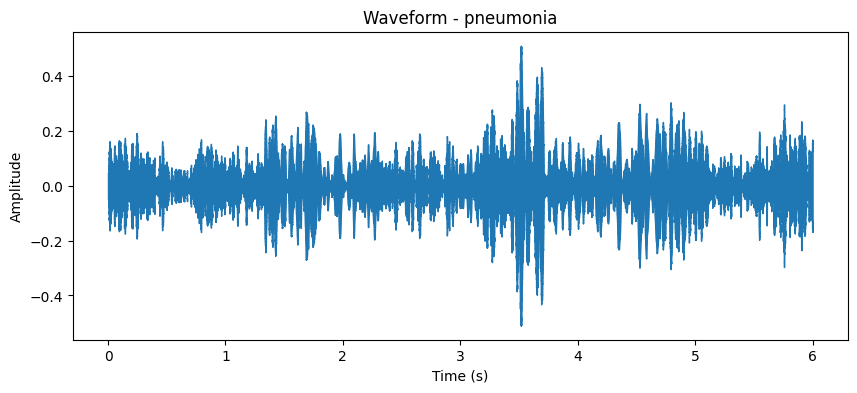

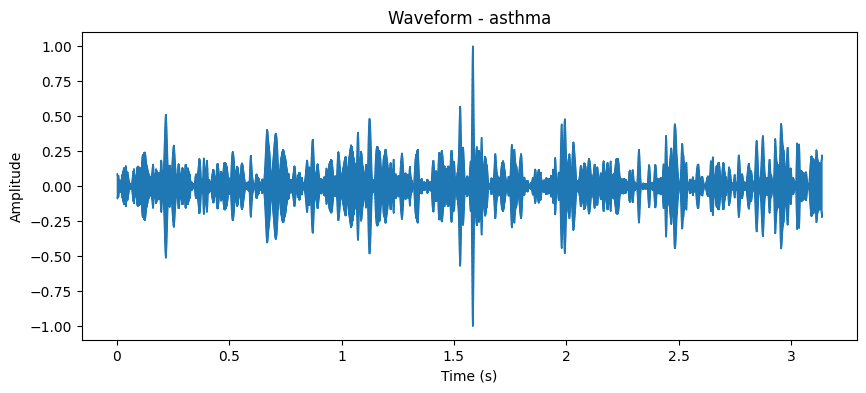

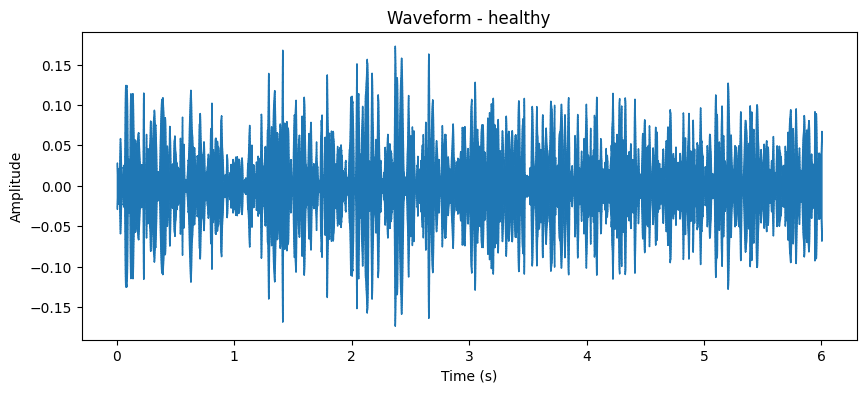

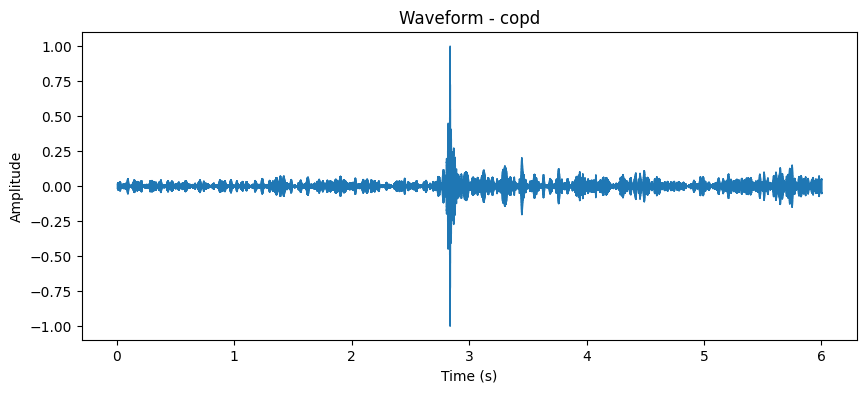

In [26]:
##############################################################################
# 5) SHOW 5 WAVEFORM PLOTS (ONE FROM EACH CATEGORY)
##############################################################################
# The user wants exactly 5 waveforms, one for each category.
# We will loop through the 5 categories, load the first audio in each folder,
# and plot the waveform using librosa.display.waveshow.
print("\n=== Waveform Examples for Each Category ===")
for i, category in enumerate(categories):
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    if i < 5:  # just making sure we match exactly 5 categories
        if audio_files:
            audio_path = os.path.join(category_path, audio_files[0])
            y, sr = librosa.load(audio_path, sr=None)
            
            plt.figure(figsize=(10, 4))
            librosa.display.waveshow(y, sr=sr)
            plt.title(f'Waveform - {category}')
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude')
            plt.show()

In [27]:
##############################################################################
# Fix 1) Rename local augmentation functions to avoid confusion
##############################################################################
def my_add_noise(audio, noise_factor=0.005):
    """Add random noise to the audio signal."""
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

def my_time_stretch(audio, rate=1.0):
    """Time-stretch audio by a certain rate, using librosa's built-in function."""
    # Note: we explicitly call librosa.effects.time_stretch with y= and rate=
    return librosa.effects.time_stretch(y=audio, rate=rate)

def my_pitch_shift(audio, sr, n_steps=0):
    """Pitch-shift audio by n_steps semitones, using librosa's built-in function."""
    return librosa.effects.pitch_shift(y=audio, sr=sr, n_steps=n_steps)

def augment_audio(y, sr):
    """
    Randomly apply one or more transformations to the audio
    to improve dataset variability.
    """
    import random
    choice = random.choice(['noise', 'stretch', 'pitch', 'none'])
    
    if choice == 'noise':
        return my_add_noise(y)
    elif choice == 'stretch':
        rate = random.uniform(0.8, 1.2)   # random stretch factor
        return my_time_stretch(y, rate=rate)
    elif choice == 'pitch':
        steps = random.uniform(-2, 2)     # random pitch shift in semitones
        return my_pitch_shift(y, sr, n_steps=steps)
    else:
        return y  # no augmentation


In [28]:
#############################################################################
# NEW: DATA AUGMENTATION + HANDLING CLASS IMBALANCE
# We'll find the largest category count and oversample the others by 
# generating augmented audio until each category matches the largest count.
##############################################################################
print("\n=== Data Augmentation and Class Balancing ===")
max_count = max(category_counts.values())

all_audio_data = []   # Will store (audio_array, sr, label)
for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    current_count = len(audio_files)
    
    # Load original audio
    loaded_signals = []
    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)
        y_load, sr_load = librosa.load(audio_path, sr=None)
        loaded_signals.append((y_load, sr_load))
        all_audio_data.append((y_load, sr_load, category))
    
    # If category is underrepresented, generate augmented samples
    if current_count < max_count:
        needed = max_count - current_count
        # Randomly augment from existing signals
        for _ in range(needed):
            # pick a random original signal
            orig_y, orig_sr = random.choice(loaded_signals)
            # apply augmentation
            y_aug = augment_audio(orig_y, orig_sr)
            all_audio_data.append((y_aug, orig_sr, category))

# Now we have an augmented list "all_audio_data" 
# with all categories having the same number of samples.


=== Data Augmentation and Class Balancing ===


In [29]:
##############################################################################
# 18) FEATURE EXTRACTION FOR MODEL TRAINING (MFCC MEAN FEATURES)
##############################################################################
# We'll now extract features for the classification model.
'''print("\n=== Preparing Features and Labels for Model ===")
feature_list = []
labels_list = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    for audio_file in audio_files:
        audio_path = os.path.join(category_path, audio_file)
        y_data, sr_data = librosa.load(audio_path, sr=None)
        # Extract MFCC (13)
        mfcc_data = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)
        # Take mean across time frames
        feature_list.append(np.mean(mfcc_data, axis=1))
        labels_list.append(category)

X = np.array(feature_list)
y = np.array(labels_list)

print("Total Samples:", len(feature_list))
print("Feature Shape:", X.shape)'''


'print("\n=== Preparing Features and Labels for Model ===")\nfeature_list = []\nlabels_list = []\n\nfor category in categories:\n    category_path = os.path.join(dataset_path, category)\n    audio_files = [f for f in os.listdir(category_path) if f.endswith(\'.wav\')]\n    for audio_file in audio_files:\n        audio_path = os.path.join(category_path, audio_file)\n        y_data, sr_data = librosa.load(audio_path, sr=None)\n        # Extract MFCC (13)\n        mfcc_data = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)\n        # Take mean across time frames\n        feature_list.append(np.mean(mfcc_data, axis=1))\n        labels_list.append(category)\n\nX = np.array(feature_list)\ny = np.array(labels_list)\n\nprint("Total Samples:", len(feature_list))\nprint("Feature Shape:", X.shape)'

In [30]:
##############################################################################
# 18) FEATURE EXTRACTION FOR MODEL TRAINING (MFCC MEAN FEATURES)
##############################################################################
# We'll now extract features for the classification model.
feature_list = []
labels_list = []

max_len = 517  # you can tune this

for y_data, sr_data, category in all_audio_data:
    mfcc = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)
    mfcc = mfcc.T  # (time_steps, 13)

    # Pad or truncate
    if mfcc.shape[0] < max_len:
        pad_width = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:max_len, :]

    feature_list.append(mfcc)
    labels_list.append(category)

X = np.array(feature_list)   # shape: (samples, time_steps, 13)
y = np.array(labels_list)

c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1920
  warnings.warn(


In [31]:
##############################################################################
# 19) LABEL ENCODING
##############################################################################
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print("Labels Shape:", y_encoded.shape)

Labels Shape: (2005,)


In [32]:
##############################################################################
# 20) TRAIN-TEST SPLIT (80/20) AS REQUESTED
##############################################################################
# We will specifically do 80/20, as per your preference (test_size=0.2).
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 1604
Testing Samples: 401


In [33]:
##############################################################################
# 21) RESHAPE FOR LSTM (SAMPLES, TIMESTEPS, 1)
##############################################################################
# LSTM expects 3D input: (batch_size, timesteps, channels).
'''X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)'''

'X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)\nX_test  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)'

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dropout, Dense

model = Sequential()

# Conv layers (feature extraction)
model.add(Conv1D(
    filters=32,
    kernel_size=3,
    activation='relu',
    input_shape=(X_train.shape[1], X_train.shape[2])
))

model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu'
))

model.add(MaxPooling1D(pool_size=2))

# LSTM layers (temporal learning)
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(64))

# Regularization
model.add(Dropout(0.3))

# Dense layers
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y_encoded)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 515, 32)        │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 513, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 256, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,021 (304.77 KB)

 Trainable params: 78,021 (304.77 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
X_train

array([[[-4.15055664e+02,  1.45068390e+02,  4.13007736e+01, ...,
          9.99370289e+00,  1.41554146e+01,  1.21067295e+01],
        [-4.46557617e+02,  1.46719589e+02,  6.03435593e+01, ...,
          1.18701763e+01,  1.81142101e+01,  1.86698761e+01],
        [-4.81817352e+02,  1.32971619e+02,  7.73174438e+01, ...,
          9.52941704e+00,  1.89551353e+01,  2.50114918e+01],
        ...,
        [-4.83589996e+02,  1.31667343e+02,  7.69305115e+01, ...,
          1.72187691e+01,  1.51509180e+01,  1.19170046e+01],
        [-4.81486755e+02,  1.34240326e+02,  7.81077652e+01, ...,
          2.34837723e+01,  1.93908157e+01,  1.01642628e+01],
        [-4.66175385e+02,  1.44612106e+02,  7.41349335e+01, ...,
          2.08747635e+01,  1.78967743e+01,  1.08837957e+01]],

       [[-3.07310913e+02,  9.19389343e+01,  3.78694916e+01, ...,
          4.03232527e+00,  8.35206985e+00,  1.45550804e+01],
        [-3.47520660e+02,  1.17589249e+02,  4.35567703e+01, ...,
          1.02466476e+00,  9.57993889e

In [36]:
##############################################################################
# 23) TRAIN THE MODEL (SHOW TRAINING & VALIDATION ACCURACY)
##############################################################################
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.3811 - loss: 1.4378 - val_accuracy: 0.3551 - val_loss: 1.3700
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.4404 - loss: 1.2666 - val_accuracy: 0.5047 - val_loss: 1.2609
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.4856 - loss: 1.2127 - val_accuracy: 0.4829 - val_loss: 1.3264
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.5019 - loss: 1.1847 - val_accuracy: 0.5296 - val_loss: 1.1673
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.5222 - loss: 1.1444 - val_accuracy: 0.5732 - val_loss: 1.1780
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5690 - loss: 1.1089 - val_accuracy: 0.5763 - val_loss: 1.0715
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.5666 - loss: 1.1024 - val_accuracy: 0.5888 - val_loss: 1.0527
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.5253 - loss: 1.1392 - val_accuracy: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step

Model Performance Metrics:
Accuracy: 0.6509
Precision: 0.7289
Recall: 0.6509
F1-Score: 0.6434

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.77      0.71        82
           1       0.50      0.95      0.65        74
           2       0.93      0.36      0.52        75
           3       0.65      0.64      0.65        87
           4       0.90      0.54      0.68        83

    accuracy                           0.65       401
   macro avg       0.73      0.65      0.64       401
weighted avg       0.73      0.65      0.64       401



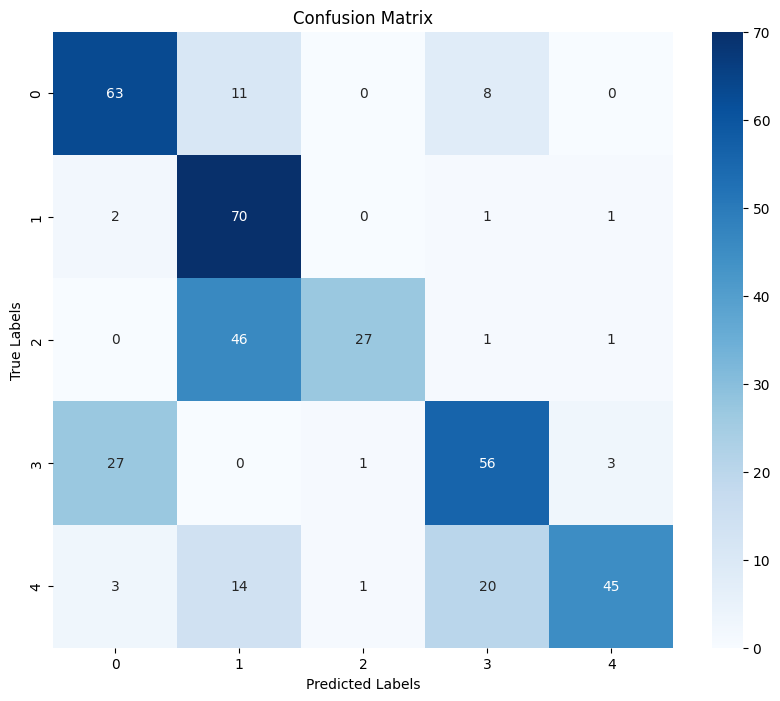

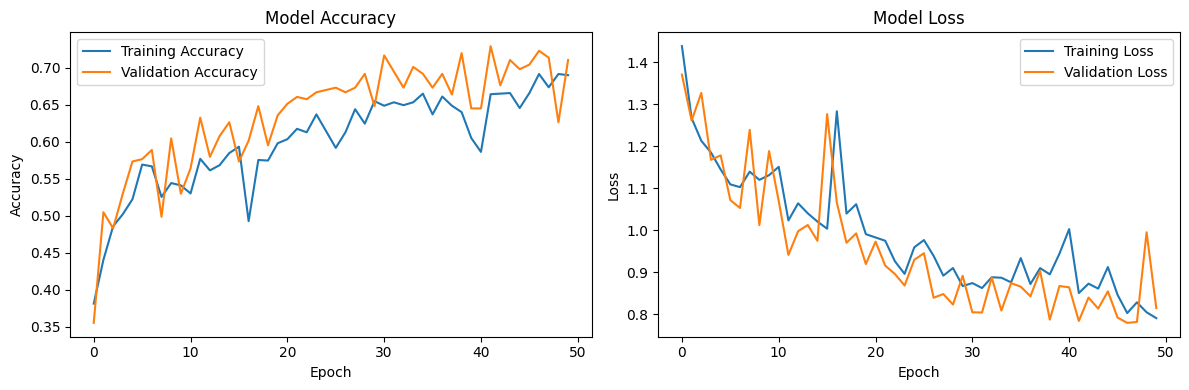

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Make predictions on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Print results
print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Visualize confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

# Plot training accuracy and loss
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# **Trying to improve output**

In [38]:
import os
import random
import numpy as np
import librosa
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dropout, Flatten, Dense
from tensorflow.keras.utils import to_categorical

##############################################################################
# 1) DATA AUGMENTATION AND CLASS BALANCING
##############################################################################

print("\n=== Data Augmentation and Class Balancing ===")

# Example: define this function for augmentations (pitch shift, noise, etc.)
def augment_audio(y, sr):
    # pitch shift example
    y_aug = librosa.effects.pitch_shift(y, sr=sr, n_steps=random.uniform(-2, 2))
    # add small Gaussian noise
    y_aug += 0.005 * np.random.randn(len(y_aug))
    return y_aug

dataset_path = r"C:\Users\omarz\OneDrive\Desktop\p2m\respiratory_diseases\Asthma Detection Dataset Version 2\Asthma Detection Dataset Version 2"
categories = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

# Count samples per category
category_counts = {cat: len(os.listdir(os.path.join(dataset_path, cat))) for cat in categories}
max_count = max(category_counts.values())

all_audio_data = []

for category in categories:
    category_path = os.path.join(dataset_path, category)
    audio_files = [f for f in os.listdir(category_path) if f.endswith('.wav')]
    loaded_signals = []

    for audio_file in audio_files:
        y_load, sr_load = librosa.load(os.path.join(category_path, audio_file), sr=None)
        loaded_signals.append((y_load, sr_load))
        all_audio_data.append((y_load, sr_load, category))

    # Oversample with augmentation
    if len(audio_files) < max_count:
        needed = max_count - len(audio_files)
        for _ in range(needed):
            orig_y, orig_sr = random.choice(loaded_signals)
            y_aug = augment_audio(orig_y, orig_sr)
            all_audio_data.append((y_aug, orig_sr, category))

print(f"Total audio samples after augmentation: {len(all_audio_data)}")

##############################################################################
# 2) FEATURE EXTRACTION (MFCC) WITH DYNAMIC max_len
##############################################################################

# First, compute lengths to choose max_len dynamically
all_lengths = [librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13).shape[1] for y, sr, _ in all_audio_data]
max_len = int(np.percentile(all_lengths, 90))  # 90th percentile to cover most audio
print(f"Chosen max_len based on dataset: {max_len}")

feature_list = []
labels_list = []

for y_data, sr_data, category in all_audio_data:
    mfcc = librosa.feature.mfcc(y=y_data, sr=sr_data, n_mfcc=13)
    mfcc = mfcc.T  # (time_steps, n_mfcc)

    # Pad or truncate to max_len
    if mfcc.shape[0] < max_len:
        pad_width = max_len - mfcc.shape[0]
        mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:max_len, :]

    feature_list.append(mfcc)
    labels_list.append(category)

X = np.array(feature_list)  # shape: (samples, time_steps, 13)
y = np.array(labels_list)

print("Feature array shape:", X.shape)
print("Labels array shape:", y.shape)

##############################################################################
# 3) LABEL ENCODING
##############################################################################

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
print("Encoded labels shape:", y_encoded.shape)

##############################################################################
# 4) TRAIN/TEST SPLIT
##############################################################################

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

##############################################################################
# 5) LSTM MODEL
##############################################################################

# LSTM expects 3D input (samples, timesteps, features)
input_shape = (X_train.shape[1], X_train.shape[2])

model = Sequential()
model.add(Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape))
model.add(Conv1D(64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(64, return_sequences=True))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y_encoded)), activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

##############################################################################
# 6) READY TO TRAIN
##############################################################################
# Example:
# history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
#                     epochs=50, batch_size=32)


=== Data Augmentation and Class Balancing ===
Total audio samples after augmentation: 2005


c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1920
  warnings.warn(


Chosen max_len based on dataset: 517
Feature array shape: (2005, 517, 13)
Labels array shape: (2005,)
Encoded labels shape: (2005,)
Training samples: 1604
Testing samples: 401


c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 515, 32)        │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 513, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 256, 64)        │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,021 (304.77 KB)

 Trainable params: 78,021 (304.77 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
##############################################################################
# 23) TRAIN THE MODEL (SHOW TRAINING & VALIDATION ACCURACY)
##############################################################################
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.4147 - loss: 1.4131 - val_accuracy: 0.3427 - val_loss: 1.4509
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.4973 - loss: 1.2182 - val_accuracy: 0.5732 - val_loss: 1.1078
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - accuracy: 0.5121 - loss: 1.1619 - val_accuracy: 0.5701 - val_loss: 1.1121
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.5596 - loss: 1.0869 - val_accuracy: 0.4393 - val_loss: 1.2961
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.4692 - loss: 1.2399 - val_accuracy: 0.5639 - val_loss: 1.1014
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5261 - loss: 1.1106 - val_accuracy: 0.5327 - val_loss: 1.1021
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - accuracy: 0.5526 - loss: 1.0777 - val_accuracy: 0.6106 - val_loss: 1.0161
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.5534 - loss: 1.0631 - val_accuracy: 0.

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step

Model Performance Metrics:
Accuracy: 0.6160
Precision: 0.6894
Recall: 0.6160
F1-Score: 0.6042

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.70      0.70        80
           1       0.53      0.86      0.66        80
           2       0.91      0.39      0.54        80
           3       0.51      0.75      0.61        81
           4       0.79      0.38      0.51        80

    accuracy                           0.62       401
   macro avg       0.69      0.62      0.60       401
weighted avg       0.69      0.62      0.60       401



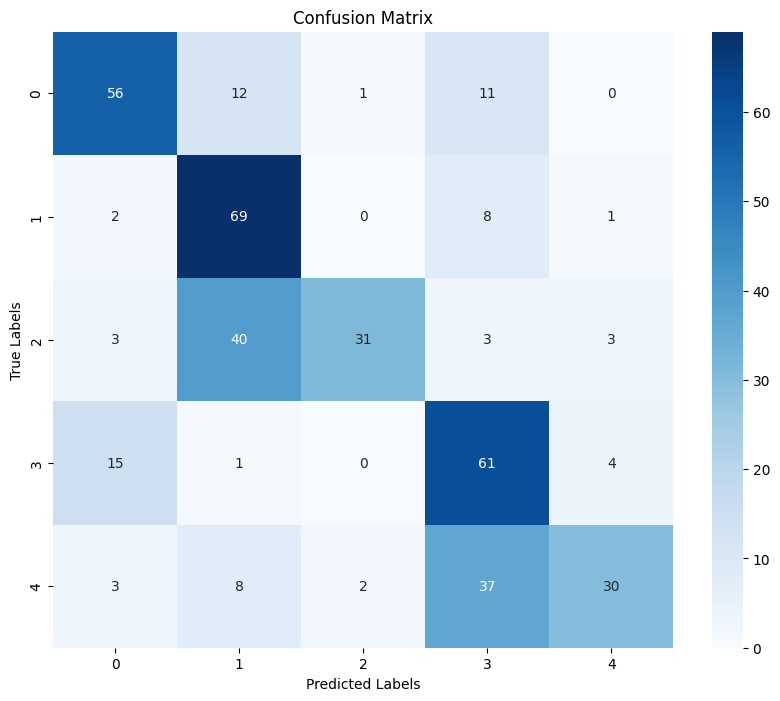

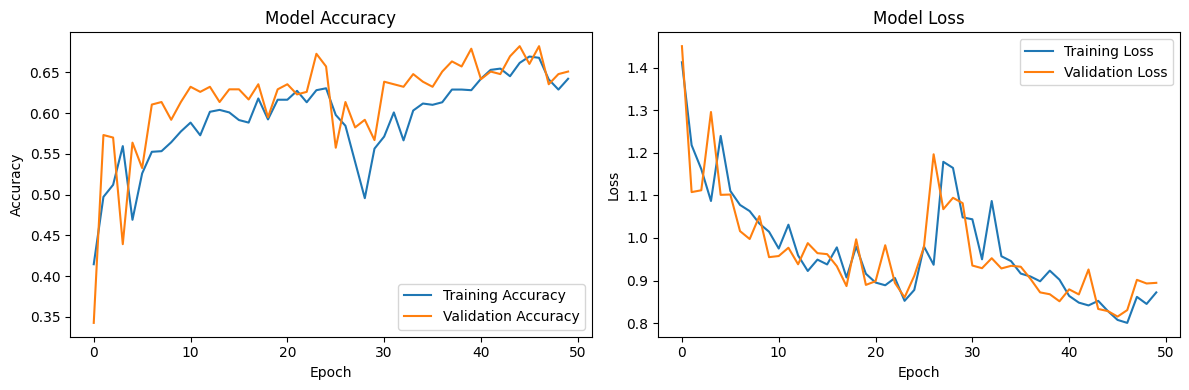

In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Make predictions on test data
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Print results
print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Visualize confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

# Plot training accuracy and loss
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Do not continue below**

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


C:\Users\omarz\AppData\Local\Temp\ipykernel_31552\1778060215.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


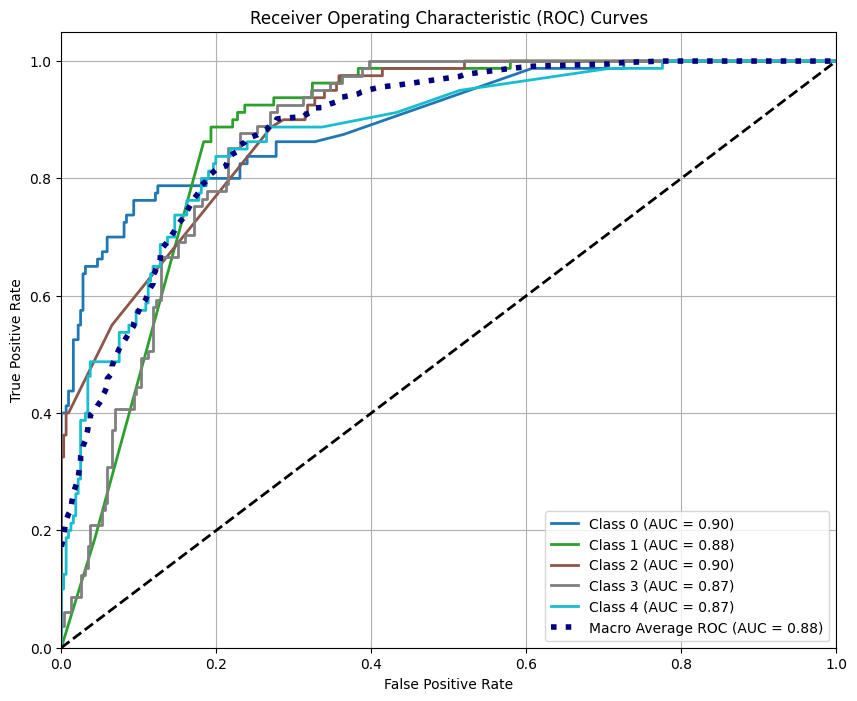


AUC Scores:
Class 0: 0.8977
Class 1: 0.8777
Class 2: 0.8969
Class 3: 0.8738
Class 4: 0.8737
Macro Average AUC: 0.8850


In [41]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

def plot_roc_curves(y_test, y_pred_proba):
    """
    Plots ROC curves for multiclass classification

    Parameters:
    y_test: True labels
    y_pred_proba: Predicted probabilities from the model
    """

    # Determine number of classes
    n_classes = y_pred_proba.shape[1]

    # Initialize dictionaries
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # One-hot encode true labels
    y_test_bin = np.eye(n_classes)[y_test]

    # Compute ROC curve for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute macro-average ROC curve
    fpr_mean = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    tpr_mean = np.zeros_like(fpr_mean)

    for i in range(n_classes):
        tpr_mean += np.interp(fpr_mean, fpr[i], tpr[i])

    tpr_mean = tpr_mean / n_classes

    fpr["macro"] = fpr_mean
    tpr["macro"] = tpr_mean
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # Plot ROC curves
    plt.figure(figsize=(10, 8))

    colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    # Plot macro-average ROC
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro Average ROC (AUC = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)

    # Reference line
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curves')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return roc_auc

# Get predicted probabilities
y_pred_proba = model.predict(X_test)

# Plot ROC curves and get AUC scores
roc_auc_scores = plot_roc_curves(y_test, y_pred_proba)

# Print AUC scores
print("\nAUC Scores:")
for i in range(len(np.unique(y_test))):
    print(f"Class {i}: {roc_auc_scores[i]:.4f}")

print(f"Macro Average AUC: {roc_auc_scores['macro']:.4f}")

In [42]:
##############################################################################
# 21) RESHAPE FOR LSTM (SAMPLES, TIMESTEPS, 1)
##############################################################################
# LSTM expects 3D input: (batch_size, timesteps, channels).
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test  = X_test.reshape(X_test.shape[0], X_test.shape[1])

ValueError: cannot reshape array of size 10780484 into shape (1604,517)

In [ ]:
model = Sequential()

model.add(Conv1D(filters=32, kernel_size=3, activation='relu',
                 input_shape=(X_train.shape[1], 1), padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))

model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y_encoded)), activation='softmax'))


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

c:\Users\omarz\anaconda3\envs\mon_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 13, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 6, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,013 (74.27 KB)

 Trainable params: 19,013 (74.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
##############################################################################
# 23) TRAIN THE MODEL (SHOW TRAINING & VALIDATION ACCURACY)
##############################################################################
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2752 - loss: 11.1841 - val_accuracy: 0.1856 - val_loss: 4.9253
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3592 - loss: 4.6388 - val_accuracy: 0.3660 - val_loss: 2.7880
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3902 - loss: 2.7294 - val_accuracy: 0.5103 - val_loss: 1.4626
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4199 - loss: 1.9222 - val_accuracy: 0.6134 - val_loss: 1.2045
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4871 - loss: 1.3729 - val_accuracy: 0.5979 - val_loss: 1.1158
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5401 - loss: 1.2519 - val_accuracy: 0.6598 - val_loss: 1.0190
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5478 - loss: 1.1610 - val_accuracy: 0.7062 - val_loss: 0.9999
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6344 - loss: 0.9987 - val_accuracy: 0.6907 - val_

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step

Model Performans Metrikleri:
Accuracy: 0.7860
Precision: 0.7893
Recall: 0.7860
F1-Score: 0.7772

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.69      0.81      0.74        57
           2       0.90      0.89      0.90        74
           3       0.75      0.33      0.46        27
           4       0.75      0.82      0.78        65

    accuracy                           0.79       243
   macro avg       0.79      0.74      0.75       243
weighted avg       0.79      0.79      0.78       243



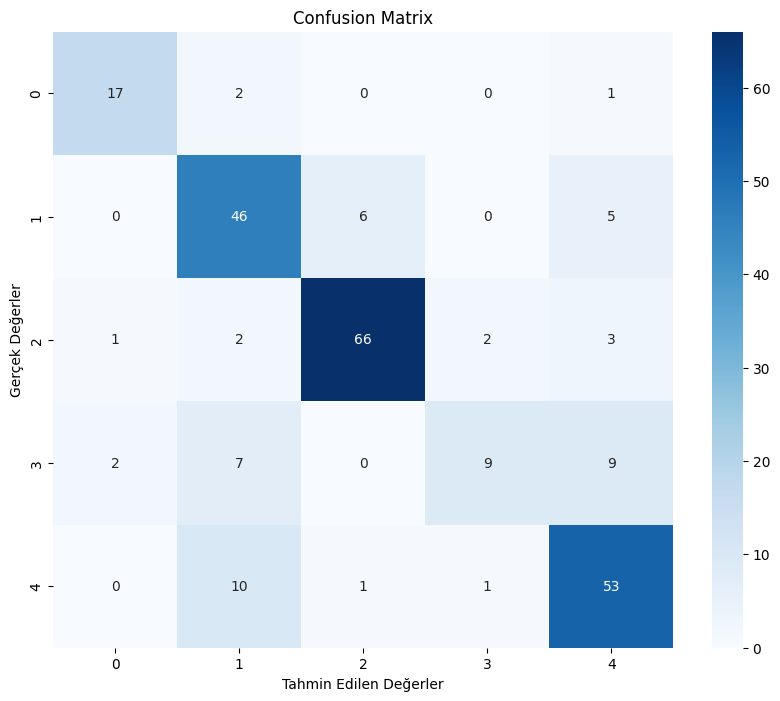

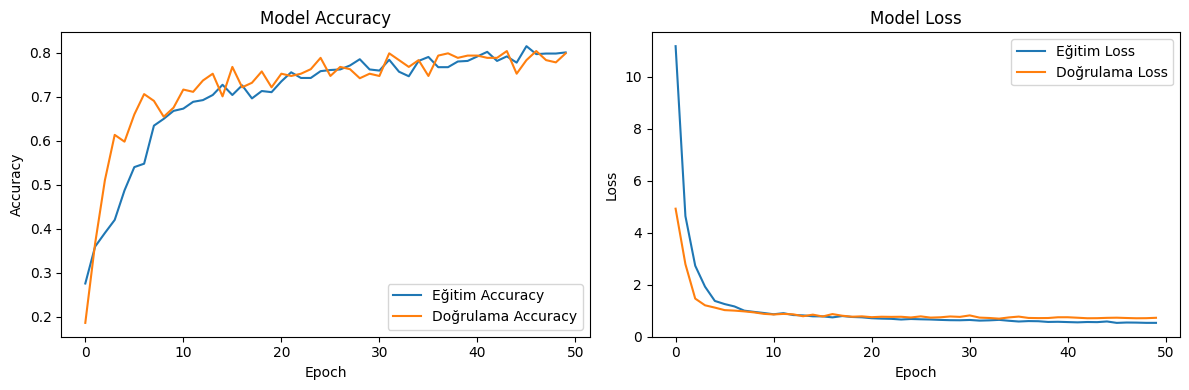

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

# Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Metrikleri hesapla
accuracy = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average='weighted')
recall = recall_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

# Sonuçları yazdır
print("\nModel Performans Metrikleri:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Detaylı sınıflandırma raporu
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred_classes))

# Confusion Matrix için
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix oluştur
cm = confusion_matrix(y_test, y_pred_classes)

# Confusion Matrix'i görselleştir
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# Eğitim sürecindeki accuracy ve loss değerlerinin grafiğini çiz
plt.figure(figsize=(12, 4))

# Accuracy grafiği
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Eğitim Accuracy')
plt.plot(history.history['val_accuracy'], label='Doğrulama Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Eğitim Loss')
plt.plot(history.history['val_loss'], label='Doğrulama Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# sadece cnn kullanınca daha iyi sonuç verdi